# 1. List comprehensions: concise transformations with explicit meaning

Learn to translate a loop into a comprehension, distinguish filtering from replacing values, and preserve the association between records and outcomes. Prerequisite: [Scope](../../../01_Python_Foundations/07_scope.ipynb). Allow two hours, including predicting output lengths before execution. Concise code is the goal only when its meaning remains clear; no model is trained here.

## 2. What problem does this solve?

Many data operations build a new list by transforming each observation. Repeating an accumulator-and-append loop can obscure the simple transformation. A comprehension expresses “produce this result for each selected item” directly. It is useful for feature construction, labels, and small transformations before numerical arrays are needed.

However, a one-line expression can also hide which rows were removed. In supervised learning, filtering features without applying the same selection to targets corrupts examples even when the code runs. We will inspect output length and record identity alongside values.

## 3. Intuition and analogy

Imagine an assembly line. Each input item passes a selection gate, then a transformation makes the output. A filtering comprehension may remove some inputs entirely. A conditional expression instead sends every input forward but chooses a different output for some items.

Those two arrangements answer different questions. If a measurement is unavailable, preserving its row with a missing marker may be essential. If a documented validity rule excludes the entire record, filtering the complete record may be appropriate. Choose the information rule before choosing syntax.

## 4. Terminology

A **comprehension** constructs a collection from an iterable using a transformation and optional filters. A **mapping** operation transforms items while retaining their correspondence. **Filtering** selects a subset. A **conditional expression** chooses one of two values using `yes_value if condition else no_value`.

A **nested comprehension** contains more than one iteration clause. **Flattening** combines nested sequences into one sequence. A **generator expression** produces values lazily rather than building the whole list immediately. **Alignment** means each value still corresponds to the intended record, feature, or target.

## 5. Mathematical foundations

For a numerical sequence $x_1,\ldots,x_n$, elementwise squaring produces $z_i=x_i^2$. There are still n results, each associated with its original index. If x is dimensionless, z is dimensionless; if x is a distance, z has squared-distance units.

Filtering with condition $C(x_i)$ creates only those outputs whose condition is true. Its output length is

$$m=\sum_{i=1}^{n}\mathbf{1}[C(x_i)].$$

The indicator is one for selected rows and zero otherwise. m may be smaller than n. If target values describe the original n rows, they must be selected by the same original indices; simply zipping the shortened feature sequence with the original target sequence is incorrect.

## 6. Hand-calculated example

For `[0,1,2,3]`, squaring every entry gives `[0,1,4,9]`, length four. Selecting even inputs first gives `[0,2]`, then squaring gives `[0,4]`, length two. Replacing odd-input results with `None` gives `[0,None,4,None]`, still length four.

These results encode different decisions. `None` is an explicit absence marker, not a zero or a numerical error. A later numerical tool will need a documented strategy for missing values; this lesson preserves the distinction rather than silently filling them.

## 7. Implementation from scratch

In [1]:
# Enable embedded figures in this fresh notebook kernel.
from IPython import get_ipython
get_ipython().run_line_magic('matplotlib', 'inline')

In [2]:
values = [0, 1, 2, 3]
all_squares = []
even_squares = []
preserved = []
for value in values:
    all_squares.append(value ** 2)
    if value % 2 == 0:
        even_squares.append(value ** 2)
        preserved.append(value ** 2)
    else:
        preserved.append(None)
assert all_squares == [0, 1, 4, 9]
assert even_squares == [0, 4]
assert preserved == [0, None, 4, None]

## 8. Comprehensions and output inspection

In [3]:
mapped = [value ** 2 for value in values]
filtered = [value ** 2 for value in values if value % 2 == 0]
replaced = [value ** 2 if value % 2 == 0 else None for value in values]
assert mapped == all_squares and filtered == even_squares and replaced == preserved
print('Map:', mapped, 'length:', len(mapped))
print('Filter then map:', filtered, 'length:', len(filtered))
print('Conditional replacement:', replaced, 'length:', len(replaced))

Map: [0, 1, 4, 9] length: 4
Filter then map: [0, 4] length: 2
Conditional replacement: [0, None, 4, None] length: 4


Read the filter version as “square value, for each value in values, if value is even.” The condition after the iteration removes items. In the replacement version, the conditional expression before `for` supplies one output for every input. Placement changes semantics, not just style.

## 9. Numerical-library comparison

NumPy offers Boolean masking for selection and `where` for choosing elementwise outputs. It uses `np.nan` as a floating-point missing marker in this example, rather than Python's `None`.

In [4]:
import numpy as np
array = np.array(values, dtype=float)
mask = (array % 2) == 0
np.testing.assert_allclose(array ** 2, mapped)
np.testing.assert_allclose((array ** 2)[mask], filtered)
numeric_replaced = np.where(mask, array ** 2, np.nan)
np.testing.assert_allclose(numeric_replaced, [0, np.nan, 4, np.nan], equal_nan=True)
print('NumPy selection:', array[mask], 'Replacement:', numeric_replaced)

NumPy selection: [0. 2.] Replacement: [ 0. nan  4. nan]


The library expresses whole-array operations and supports numerical broadcasting. A Python comprehension is often easier for mixed objects and small record-oriented transformations. `np.where` evaluates its candidate arrays; do not use it as if it prevents an invalid operation in a branch from being calculated.

## 10. Visualization

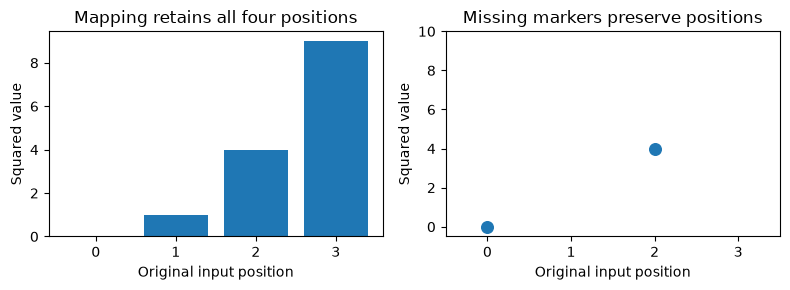

In [5]:
import matplotlib.pyplot as plt
from IPython.display import display
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].bar(values, mapped)
axes[0].set(xlabel='Original input position', ylabel='Squared value', title='Mapping retains all four positions', xticks=values)
axes[1].scatter(values, numeric_replaced, s=70)
axes[1].set(xlabel='Original input position', ylabel='Squared value', title='Missing markers preserve positions', xticks=values, xlim=(-0.5, 3.5), ylim=(-0.5, 10))
fig.tight_layout()
display(fig)
plt.close(fig)

The second plot has points only at positions zero and two. Missing values are not plotted as zeros. Their absent positions remain visible in the axis domain; plotting only a shortened list without original positions would conceal where observations were removed.

## 11. Realistic experiment: features and targets must move together

Four invented records have IDs and quantities. Reject missing and negative quantities, but preserve IDs and their matching target categories in complete selected records.

In [6]:
records = [{'id': 101, 'quantity': 0, 'target': 'A'},
           {'id': 102, 'quantity': -1, 'target': 'B'},
           {'id': 103, 'quantity': 2, 'target': 'C'},
           {'id': 104, 'quantity': None, 'target': 'D'}]
selected = [row for row in records if row['quantity'] is not None and row['quantity'] >= 0]
features = [row['quantity'] ** 2 for row in selected]
targets = [row['target'] for row in selected]
ids = [row['id'] for row in selected]
assert ids == [101, 103] and features == [0, 4] and targets == ['A', 'C']
wrong_pairs = list(zip(features, [row['target'] for row in records]))
assert wrong_pairs == [(0, 'A'), (4, 'B')]
assert wrong_pairs != list(zip(features, targets))
print('Correct selected identities:', ids, 'Targets:', targets)

Correct selected identities: [101, 103] Targets: ['A', 'C']


The deliberately wrong pairs demonstrate the failure without fitting a model to them. Equal-looking lengths after a truncating zip do not validate correspondence. Preserve identity until you can verify how arrays were derived.

## 12. Choices and experiments

Choose whether to preserve, replace, or exclude an observation based on the data protocol. These are processing choices, not learned parameters. Try the same operation as a loop and comprehension, then compare values, order, and lengths. Use a generator expression when consuming values once for a summary, such as `sum(value ** 2 for value in values)`, and no intermediate list is needed.

## 13. Evaluation

Check exact small values and original positions. Verify row identities when transformations produce model inputs. A comprehension has its own iteration-variable scope in Python 3, so its loop name does not overwrite an outer name. That does not make referenced mutable objects independent copies.

In [7]:
value = 'outside'
check = [value ** 2 for value in [1, 2, 3]]
assert value == 'outside' and check == [1, 4, 9]
assert sum(item ** 2 for item in values) == sum(mapped) == 14

## 14. Assumptions and limitations

Comprehensions build their collections in memory. Very large outputs can consume substantial space even though the code is one line. Selection rules may bias retained data and need statistical justification. Our record validator assumes ordinary numeric quantities except `None`; a production version would also check types, finiteness, and domain constraints.

## 15. Common mistakes and debugging

Do not filter feature and target lists independently. Do not assume a short comprehension copies nested records; the selected dictionaries above are still the original objects. Avoid deeply nested expressions with several conditions when a named loop is clearer. Do not call a function only for its side effects inside a comprehension intended to create an unused list.

## 16. Comparison with alternatives

A loop is best when you need trace output, several state updates, or rejection reasons. A comprehension suits a readable collection transformation. A generator expression supports one-pass consumption with less intermediate storage. NumPy and pandas suit large numerical or tabular operations. The same semantics should remain clear across each representation.

## 17. Exercises

1. **Beginner:** Produce cubes of `[1,2,3]` and calculate the answer manually.
2. **Beginner:** Filter positive values from `[-1,0,2]`; explain whether zero is included.
3. **Beginner:** Replace negative values with `None` while keeping all three positions.
4. **Intermediate:** Flatten `[[1,2],[],[3]]`, tracing the order of nested iteration clauses.
5. **Intermediate:** Explain why a selected list of row dictionaries can still change the original dictionaries when edited.
6. **Challenge:** Transform a list of complete labeled records into valid `(id, feature, target)` tuples and a separate rejected-ID list. Prove that no ID is lost or duplicated by the selection.

## 18. Detailed solutions

1. Cubes are one, eight, and 27; `[x ** 3 for x in [1,2,3]]` produces those values.
2. `[x for x in [-1,0,2] if x > 0]` gives `[2]`. Zero is excluded by the strict comparison.
3. `[None if x < 0 else x for x in [-1,0,2]]` gives `[None,0,2]`, preserving row count.
4. `[item for row in nested for item in row]` visits the outer row first, then each inner item. The empty row contributes no items, giving `[1,2,3]`.
5. The list is new, but its elements reference the original dictionaries. Copy rows if independent mutation is intended.
6. Use one validity decision per original row, then derive both collections from that shared decision. The proof assumes original IDs are unique, which we check explicitly.

In [8]:
decisions = [(row, row['quantity'] is not None and row['quantity'] >= 0) for row in records]
valid_tuples = [(row['id'], row['quantity'] ** 2, row['target']) for row, valid in decisions if valid]
rejected_ids = [row['id'] for row, valid in decisions if not valid]
original_ids = [row['id'] for row in records]
accepted_ids = [item[0] for item in valid_tuples]
assert len(set(original_ids)) == len(original_ids)
assert set(accepted_ids).isdisjoint(rejected_ids)
assert set(accepted_ids) | set(rejected_ids) == set(original_ids)
assert len(accepted_ids) + len(rejected_ids) == len(original_ids)
assert valid_tuples == [(101, 0, 'A'), (103, 4, 'C')]
assert rejected_ids == [102, 104]
assert [item for row in [[1, 2], [], [3]] for item in row] == [1, 2, 3]
print('Accepted tuples:', valid_tuples, 'Rejected IDs:', rejected_ids)

Accepted tuples: [(101, 0, 'A'), (103, 4, 'C')] Rejected IDs: [102, 104]


## 19. Knowledge check

**Does mapping usually change length?** Not when one output is produced per input. **Can filtering change length?** Yes. **Does a conditional expression require dropping rows?** No. **Are selected dictionaries automatically copied?** No. **Why retain IDs?** To verify alignment and reconcile selection decisions.

## 20. Interview preparation

**Loop versus comprehension?** Choose the clearest representation of transformation and diagnostics. **List versus generator expression?** Eager stored collection versus lazy iteration. **Why can independent filtering corrupt training?** Features and outcomes can become attached to different original rows. **What is a nested comprehension's order?** Clauses follow the same left-to-right nesting as equivalent loops. **How check a data-selection operation?** Reconcile identities, counts, order where relevant, rejected reasons, and exact small examples.

## 21. Summary and next steps

Concise transformations still need explicit selection semantics and alignment checks. Continue to [Modules and packages](../../../01_Python_Foundations/09_modules_and_packages.ipynb), where useful tested operations become reusable Python files.